In [25]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist

df = pd.read_csv('weatherAUS.csv')

In [26]:
faltantes_df = pd.DataFrame({
    'NaN': df.isna().sum(),
    '%': (df.isna().sum() / len(df) * 100).round(2)
}).sort_values('NaN', ascending=False)
faltantes_df

,NaN,%
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


In [27]:
# Genera una nueva variable Climate basada en la clasificación de Koppen, utilizando la variable Location

location_koppen = {
    'Adelaide': 'Temperate',
    'Albany': 'Temperate',
    'Albury': 'Temperate',
    'AliceSprings': 'Arid',
    'BadgerysCreek': 'Temperate',
    'Ballarat': 'Temperate',
    'Bendigo': 'Temperate',
    'Brisbane': 'Temperate',
    'Cairns': 'Tropical',
    'Canberra': 'Temperate',
    'Cobar': 'Arid',
    'CoffsHarbour': 'Temperate',
    'Dartmoor': 'Temperate',
    'Darwin': 'Tropical',
    'GoldCoast': 'Temperate',
    'Hobart': 'Temperate',
    'Katherine': 'Tropical',
    'Launceston': 'Temperate',
    'Melbourne': 'Temperate',
    'Mildura': 'Arid',
    'Moree': 'Temperate',
    'MountGambier': 'Temperate',
    'MountGinini': 'Temperate',
    'Newcastle': 'Temperate',
    'Nhil': 'Temperate',
    'NorahHead': 'Temperate',
    'NorfolkIsland': 'Temperate',
    'Nuriootpa': 'Temperate',
    'PearceRAAF': 'Temperate',
    'Penrith': 'Temperate',
    'Perth': 'Temperate',
    'PerthAirport': 'Temperate',
    'Portland': 'Temperate',
    'Richmond': 'Temperate',
    'Sale': 'Temperate',
    'SalmonGums': 'Arid',
    'Sydney': 'Temperate',
    'SydneyAirport': 'Temperate',
    'Townsville': 'Tropical',
    'Tuggeranong': 'Temperate',
    'Uluru': 'Arid',
    'WaggaWagga': 'Temperate',
    'Walpole': 'Temperate',
    'Watsonia': 'Temperate',
    'Williamtown': 'Temperate',
    'Witchcliffe': 'Temperate',
    'Wollongong': 'Temperate',
    'Woomera': 'Arid',
}

In [28]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist

def imputar_por_proximidad(df, coords_path='australian_locations.csv', location_koppen=None):
    """
    Imputa valores faltantes usando dos fases (versión optimizada):
    Fase 1: Por ubicación más cercana del mismo clima y mismo día
    Fase 2: Por mediana (numéricas) o moda (categóricas) para los restantes
    
    Parameters:
    -----------
    df : DataFrame
        Dataset con datos meteorológicos
    coords_path : str
        Ruta al archivo CSV con coordenadas (columns: location, lat, lon)
    location_koppen : dict
        Diccionario con clasificación climática por ubicación
        
    Returns:
    --------
    DataFrame con valores imputados y reporte de imputación
    """
    
    print("=== PREPARACIÓN: Calculando distancias entre ubicaciones ===")
    
    # Cargar coordenadas
    coords = pd.read_csv(coords_path)
    
    # Añadir Climate si location_koppen está disponible
    if location_koppen:
        coords['Climate'] = coords['location'].map(location_koppen)
    
    # Calcular matriz de distancias UNA SOLA VEZ
    locations = coords['location'].values
    coords_array = coords[['lat', 'lon']].values
    dist_matrix = cdist(coords_array, coords_array, metric='euclidean')
    
    # Para cada ubicación, encontrar las más cercanas del mismo clima
    nearest_by_climate = {}
    
    for i, loc in enumerate(locations):
        climate = coords.iloc[i]['Climate']
        # Filtrar ubicaciones del mismo clima
        same_climate_mask = coords['Climate'] == climate
        same_climate_indices = coords[same_climate_mask].index.tolist()
        
        # Obtener distancias a ubicaciones del mismo clima (excluyendo la misma)
        distances = [(idx, dist_matrix[i, idx]) for idx in same_climate_indices if idx != i]
        # Ordenar por distancia
        distances.sort(key=lambda x: x[1])
        
        # Guardar lista de ubicaciones ordenadas por proximidad
        nearest_by_climate[loc] = [locations[idx] for idx, _ in distances]
    
    print(f"  → Matriz de distancias calculada para {len(locations)} ubicaciones")
    
    # Añadir Climate al dataframe si no existe
    df_imputed = df.copy()
    if 'Climate' not in df_imputed.columns and location_koppen:
        df_imputed['Climate'] = df_imputed['Location'].map(location_koppen)
    
    # Identificar columnas a imputar
    numeric_cols = df_imputed.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in ['lat', 'lon']]
    
    categorical_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
    binary_cols = ['RainToday']
    
    all_cols_to_impute = numeric_cols + categorical_cols + binary_cols
    
    # Reporte de imputación
    reporte = {col: {'fase1': 0, 'fase2': 0, 'total_nulos': df_imputed[col].isna().sum()} 
               for col in all_cols_to_impute if col in df_imputed.columns}
    
    print("\n=== FASE 1: Imputación por proximidad geográfica (optimizada) ===")
    
    # Agrupar por Date para procesar más eficientemente
    grouped = df_imputed.groupby('Date')
    
    # FASE 1: Imputación por proximidad
    for col in all_cols_to_impute:
        if col not in df_imputed.columns:
            continue
            
        total_missing = df_imputed[col].isna().sum()
        if total_missing == 0:
            continue
        
        print(f"\nProcesando {col}: {total_missing} valores faltantes")
        imputados_fase1 = 0
        
        # Procesar por fecha para reducir búsquedas
        for date, group in grouped:
            # Identificar filas con valores faltantes en este grupo
            missing_in_group = group[group[col].isna()]
            
            if len(missing_in_group) == 0:
                continue
            
            # Crear un diccionario de valores disponibles por ubicación en esta fecha
            available_values = group[group[col].notna()].set_index('Location')[col].to_dict()
            
            # Imputar cada fila faltante
            for idx, row in missing_in_group.iterrows():
                location = row['Location']
                
                # Obtener lista de ubicaciones cercanas (ya ordenadas por proximidad)
                if location not in nearest_by_climate:
                    continue
                
                nearest_locations = nearest_by_climate[location]
                
                # Buscar la primera ubicación cercana que tenga el valor disponible
                for nearest_loc in nearest_locations:
                    if nearest_loc in available_values:
                        df_imputed.loc[idx, col] = available_values[nearest_loc]
                        imputados_fase1 += 1
                        break
        
        reporte[col]['fase1'] = imputados_fase1
        print(f"  → Imputados en Fase 1: {imputados_fase1} ({imputados_fase1/total_missing*100:.1f}%)")
    
    print("\n=== FASE 2: Imputación con mediana/moda ===")
    
    # FASE 2: Imputación con mediana/moda
    for col in all_cols_to_impute:
        if col not in df_imputed.columns:
            continue
            
        missing_mask = df_imputed[col].isna()
        num_missing = missing_mask.sum()
        
        if num_missing == 0:
            continue
        
        if col in categorical_cols + binary_cols:
            # Moda para categóricas
            moda = df_imputed[col].mode()
            if len(moda) > 0:
                df_imputed.loc[missing_mask, col] = moda[0]
                reporte[col]['fase2'] = num_missing
                print(f"{col}: {num_missing} imputados con moda '{moda[0]}'")
        else:
            # Mediana para numéricas
            mediana = df_imputed[col].median()
            df_imputed.loc[missing_mask, col] = mediana
            reporte[col]['fase2'] = num_missing
            print(f"{col}: {num_missing} imputados con mediana {mediana:.2f}")
    
    # Crear DataFrame de reporte
    reporte_df = pd.DataFrame(reporte).T
    reporte_df['total_imputados'] = reporte_df['fase1'] + reporte_df['fase2']
    reporte_df['porcentaje_fase1'] = (reporte_df['fase1'] / reporte_df['total_nulos'] * 100).round(2)
    reporte_df['porcentaje_fase2'] = (reporte_df['fase2'] / reporte_df['total_nulos'] * 100).round(2)
    
    print("\n=== RESUMEN DE IMPUTACIÓN ===")
    print(reporte_df[reporte_df['total_nulos'] > 0].to_string())
    
    return df_imputed, reporte_df


# Ejemplo de uso:
# df_imputado, reporte = imputar_por_proximidad(
#     df, 
#     coords_path='australian_locations.csv',
#     location_koppen=location_koppen
# )

# Para guardar el resultado:
# df_imputado.to_csv('weather_data_imputed.csv', index=False)
# reporte.to_csv('imputation_report.csv')

In [29]:
df_imputado, reporte = imputar_por_proximidad(
    df, 
    coords_path='australian_locations.csv',
    location_koppen=location_koppen
)

# df_imputado.to_csv('weather_data_imputed.csv', index=False)
# reporte.to_csv('imputation_report.csv')

=== PREPARACIÓN: Calculando distancias entre ubicaciones ===
  → Matriz de distancias calculada para 49 ubicaciones

=== FASE 1: Imputación por proximidad geográfica (optimizada) ===

Procesando MinTemp: 1485 valores faltantes
  → Imputados en Fase 1: 1485 (100.0%)

Procesando MaxTemp: 1261 valores faltantes
  → Imputados en Fase 1: 1261 (100.0%)

Procesando Rainfall: 3261 valores faltantes
  → Imputados en Fase 1: 3261 (100.0%)

Procesando Evaporation: 62790 valores faltantes
  → Imputados en Fase 1: 62749 (99.9%)

Procesando Sunshine: 69835 valores faltantes
  → Imputados en Fase 1: 69381 (99.3%)

Procesando WindGustSpeed: 10263 valores faltantes
  → Imputados en Fase 1: 10244 (99.8%)

Procesando WindSpeed9am: 1767 valores faltantes
  → Imputados en Fase 1: 1766 (99.9%)

Procesando WindSpeed3pm: 3062 valores faltantes
  → Imputados en Fase 1: 3062 (100.0%)

Procesando Humidity9am: 2654 valores faltantes
  → Imputados en Fase 1: 2645 (99.7%)

Procesando Humidity3pm: 4507 valores falta

In [30]:
# Drop de filas con NaN en la feature objetivo. Justificación: preferimos evitar imputar la variable objetivo y correr el riesgo de introducir ruido en el dataset, porque la cantidad de datos que perdemos es relativamente baja (menos del 2.25% del dataset).
df_imputado = df_imputado.dropna(subset=['RainTomorrow'])

In [31]:
faltantes_df = pd.DataFrame({
    'NaN': df_imputado.isna().sum(),
    '%': (df_imputado.isna().sum() / len(df_imputado) * 100).round(2)
}).sort_values('NaN', ascending=False)
faltantes_df

,NaN,%
Climate,3009,2.12
Date,0,0.00
MinTemp,0,0.00
Location,0,0.00
Rainfall,0,0.00
Evaporation,0,0.00
Sunshine,0,0.00
MaxTemp,0,0.00
WindGustDir,0,0.00
WindGustSpeed,0,0.00


In [32]:
df_imputado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        142193 non-null  float64
 3   MaxTemp        142193 non-null  float64
 4   Rainfall       142193 non-null  float64
 5   Evaporation    142193 non-null  float64
 6   Sunshine       142193 non-null  float64
 7   WindGustDir    142193 non-null  object 
 8   WindGustSpeed  142193 non-null  float64
 9   WindDir9am     142193 non-null  object 
 10  WindDir3pm     142193 non-null  object 
 11  WindSpeed9am   142193 non-null  float64
 12  WindSpeed3pm   142193 non-null  float64
 13  Humidity9am    142193 non-null  float64
 14  Humidity3pm    142193 non-null  float64
 15  Pressure9am    142193 non-null  float64
 16  Pressure3pm    142193 non-null  float64
 17  Cloud9am       142193 non-null  fl

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def validar_imputacion(df_original, df_imputado, columnas=None, figsize=(15, 10)):
    """
    Valida que la imputación no haya alterado significativamente las distribuciones.
    
    Parameters:
    -----------
    df_original : DataFrame
        Dataset original con valores faltantes
    df_imputado : DataFrame
        Dataset después de la imputación
    columnas : list, optional
        Lista de columnas a validar. Si None, valida todas las numéricas.
    figsize : tuple
        Tamaño de las figuras
        
    Returns:
    --------
    DataFrame con estadísticas comparativas
    """
    
    # Seleccionar columnas numéricas si no se especifican
    if columnas is None:
        columnas = df_original.select_dtypes(include=[np.number]).columns.tolist()
        columnas = [col for col in columnas if col not in ['lat', 'lon']]
    
    # Dataframe para resultados estadísticos
    resultados = []
    
    print("=" * 80)
    print("VALIDACIÓN DE IMPUTACIÓN - ANÁLISIS DE DISTRIBUCIONES")
    print("=" * 80)
    
    for col in columnas:
        if col not in df_original.columns or col not in df_imputado.columns:
            continue
        
        # Datos originales (sin NaN)
        original_sin_nan = df_original[col].dropna()
        # Datos imputados completos
        imputado_completo = df_imputado[col].dropna()
        # Solo los valores que fueron imputados
        mask_imputados = df_original[col].isna() & df_imputado[col].notna()
        valores_imputados = df_imputado.loc[mask_imputados, col]
        
        if len(valores_imputados) == 0:
            continue
        
        # Calcular estadísticas
        stats_dict = {
            'variable': col,
            'n_imputados': len(valores_imputados),
            'pct_imputados': len(valores_imputados) / len(df_imputado) * 100,
            
            # Medidas de tendencia central
            'media_original': original_sin_nan.mean(),
            'media_imputado': imputado_completo.mean(),
            'diff_media': imputado_completo.mean() - original_sin_nan.mean(),
            
            'mediana_original': original_sin_nan.median(),
            'mediana_imputado': imputado_completo.median(),
            'diff_mediana': imputado_completo.median() - original_sin_nan.median(),
            
            # Medidas de dispersión
            'std_original': original_sin_nan.std(),
            'std_imputado': imputado_completo.std(),
            'diff_std': imputado_completo.std() - original_sin_nan.std(),
            
            # Test de Kolmogorov-Smirnov
            'ks_statistic': None,
            'ks_pvalue': None,
        }
        
        # Test KS (compara distribuciones)
        try:
            ks_stat, ks_pval = stats.ks_2samp(original_sin_nan, imputado_completo)
            stats_dict['ks_statistic'] = ks_stat
            stats_dict['ks_pvalue'] = ks_pval
        except:
            pass
        
        resultados.append(stats_dict)
    
    df_resultados = pd.DataFrame(resultados)
    
    # Mostrar resumen
    print("\n📊 RESUMEN ESTADÍSTICO")
    print("-" * 80)
    print(df_resultados[['variable', 'n_imputados', 'pct_imputados', 
                         'diff_media', 'diff_mediana', 'diff_std']].to_string(index=False))
    
    print("\n🔬 TEST DE KOLMOGOROV-SMIRNOV")
    print("-" * 80)
    print("(p-value > 0.05 indica que las distribuciones NO difieren significativamente)")
    print(df_resultados[['variable', 'ks_statistic', 'ks_pvalue']].to_string(index=False))
    
    # Interpretar resultados
    print("\n✅ INTERPRETACIÓN")
    print("-" * 80)
    problematicas = df_resultados[
        (df_resultados['ks_pvalue'] < 0.05) | 
        (abs(df_resultados['diff_media'] / df_resultados['media_original']) > 0.05)
    ]
    
    if len(problematicas) == 0:
        print("✓ Todas las variables mantienen distribuciones similares")
    else:
        print(f"⚠ {len(problematicas)} variables muestran cambios significativos:")
        for _, row in problematicas.iterrows():
            print(f"  - {row['variable']}: cambio en media de {row['diff_media']:.2f}")
    
    return df_resultados


def visualizar_comparacion_distribuciones(df_original, df_imputado, columnas=None, 
                                         max_cols=6, figsize=(18, 12)):
    """
    Visualiza comparación de distribuciones antes y después de imputación.
    
    Parameters:
    -----------
    df_original : DataFrame
        Dataset original con valores faltantes
    df_imputado : DataFrame
        Dataset después de la imputación
    columnas : list, optional
        Lista de columnas a visualizar. Si None, selecciona las más imputadas.
    max_cols : int
        Número máximo de columnas a visualizar
    """
    
    # Seleccionar columnas con más imputaciones si no se especifican
    if columnas is None:
        columnas_numericas = df_original.select_dtypes(include=[np.number]).columns.tolist()
        columnas_numericas = [col for col in columnas_numericas if col not in ['lat', 'lon']]
        
        # Ordenar por cantidad de NaN
        nans_por_col = [(col, df_original[col].isna().sum()) for col in columnas_numericas]
        nans_por_col.sort(key=lambda x: x[1], reverse=True)
        columnas = [col for col, _ in nans_por_col[:max_cols]]
    
    n_cols = len(columnas)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=figsize)
    axes = axes.flatten() if n_cols > 1 else [axes]
    
    for idx, col in enumerate(columnas):
        ax = axes[idx]
        
        # Datos
        original_sin_nan = df_original[col].dropna()
        imputado_completo = df_imputado[col].dropna()
        mask_imputados = df_original[col].isna() & df_imputado[col].notna()
        valores_imputados = df_imputado.loc[mask_imputados, col]
        
        # Histogramas superpuestos
        ax.hist(original_sin_nan, bins=50, alpha=0.5, label='Original', 
                color='blue', density=True)
        ax.hist(imputado_completo, bins=50, alpha=0.5, label='Con imputación', 
                color='green', density=True)
        ax.hist(valores_imputados, bins=50, alpha=0.7, label='Solo imputados', 
                color='red', density=True)
        
        # Líneas de media
        ax.axvline(original_sin_nan.mean(), color='blue', linestyle='--', 
                   linewidth=2, alpha=0.8)
        ax.axvline(imputado_completo.mean(), color='green', linestyle='--', 
                   linewidth=2, alpha=0.8)
        
        ax.set_title(f'{col}\n({len(valores_imputados)} imputados, '
                    f'{len(valores_imputados)/len(df_imputado)*100:.1f}%)',
                    fontsize=10, fontweight='bold')
        ax.set_xlabel('Valor')
        ax.set_ylabel('Densidad')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    
    # Ocultar ejes vacíos
    for idx in range(n_cols, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('comparacion_distribuciones.png', dpi=300, bbox_inches='tight')
    print(f"\n📊 Gráfico guardado como 'comparacion_distribuciones.png'")
    plt.show()


def visualizar_qq_plots(df_original, df_imputado, columnas=None, 
                       max_cols=6, figsize=(18, 12)):
    """
    Crea Q-Q plots para comparar distribuciones.
    Útil para verificar si los valores imputados siguen la misma distribución.
    """
    
    if columnas is None:
        columnas_numericas = df_original.select_dtypes(include=[np.number]).columns.tolist()
        columnas_numericas = [col for col in columnas_numericas if col not in ['lat', 'lon']]
        
        nans_por_col = [(col, df_original[col].isna().sum()) for col in columnas_numericas]
        nans_por_col.sort(key=lambda x: x[1], reverse=True)
        columnas = [col for col, _ in nans_por_col[:max_cols]]
    
    n_cols = len(columnas)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=figsize)
    axes = axes.flatten() if n_cols > 1 else [axes]
    
    for idx, col in enumerate(columnas):
        ax = axes[idx]
        
        original_sin_nan = df_original[col].dropna()
        mask_imputados = df_original[col].isna() & df_imputado[col].notna()
        valores_imputados = df_imputado.loc[mask_imputados, col]
        
        if len(valores_imputados) == 0:
            continue
        
        # Q-Q plot
        stats.probplot(valores_imputados, dist=stats.norm, 
                      sparams=(original_sin_nan.mean(), original_sin_nan.std()),
                      plot=ax)
        
        ax.set_title(f'Q-Q Plot: {col}\n(imputados vs distribución original)',
                    fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3)
    
    for idx in range(n_cols, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('qq_plots_imputacion.png', dpi=300, bbox_inches='tight')
    print(f"\n📊 Q-Q plots guardados como 'qq_plots_imputacion.png'")
    plt.show()


def analisis_completo_imputacion(df_original, df_imputado, columnas_clave=None):
    """
    Ejecuta análisis completo de validación de imputación.
    """
    print("\n" + "="*80)
    print("ANÁLISIS COMPLETO DE VALIDACIÓN DE IMPUTACIÓN")
    print("="*80)
    
    # 1. Estadísticas comparativas
    df_stats = validar_imputacion(df_original, df_imputado, columnas_clave)
    
    # 2. Visualizaciones
    print("\n📈 Generando visualizaciones...")
    visualizar_comparacion_distribuciones(df_original, df_imputado, columnas_clave)
    visualizar_qq_plots(df_original, df_imputado, columnas_clave)
    
    return df_stats





ANÁLISIS COMPLETO DE VALIDACIÓN DE IMPUTACIÓN
VALIDACIÓN DE IMPUTACIÓN - ANÁLISIS DE DISTRIBUCIONES

📊 RESUMEN ESTADÍSTICO
--------------------------------------------------------------------------------
     variable  n_imputados  pct_imputados  diff_media  diff_mediana  diff_std
      MinTemp          637       0.447983   -0.004484           0.0  0.004695
      MaxTemp          322       0.226453    0.006764           0.0 -0.003046
     Rainfall         1406       0.988797   -0.001678           0.0 -0.001546
  Evaporation        60843      42.789026    0.022037          -0.2  0.099035
     Sunshine        67816      47.692924   -0.023906           0.0  0.014351
WindGustSpeed         9270       6.519308    0.008745           0.0 -0.038254
 WindSpeed9am         1348       0.948007   -0.044565           0.0 -0.016191
 WindSpeed3pm         2630       1.849599   -0.007463           0.0 -0.007903
  Humidity9am         1774       1.247600    0.034249           0.0  0.013068
  Humidity3pm  

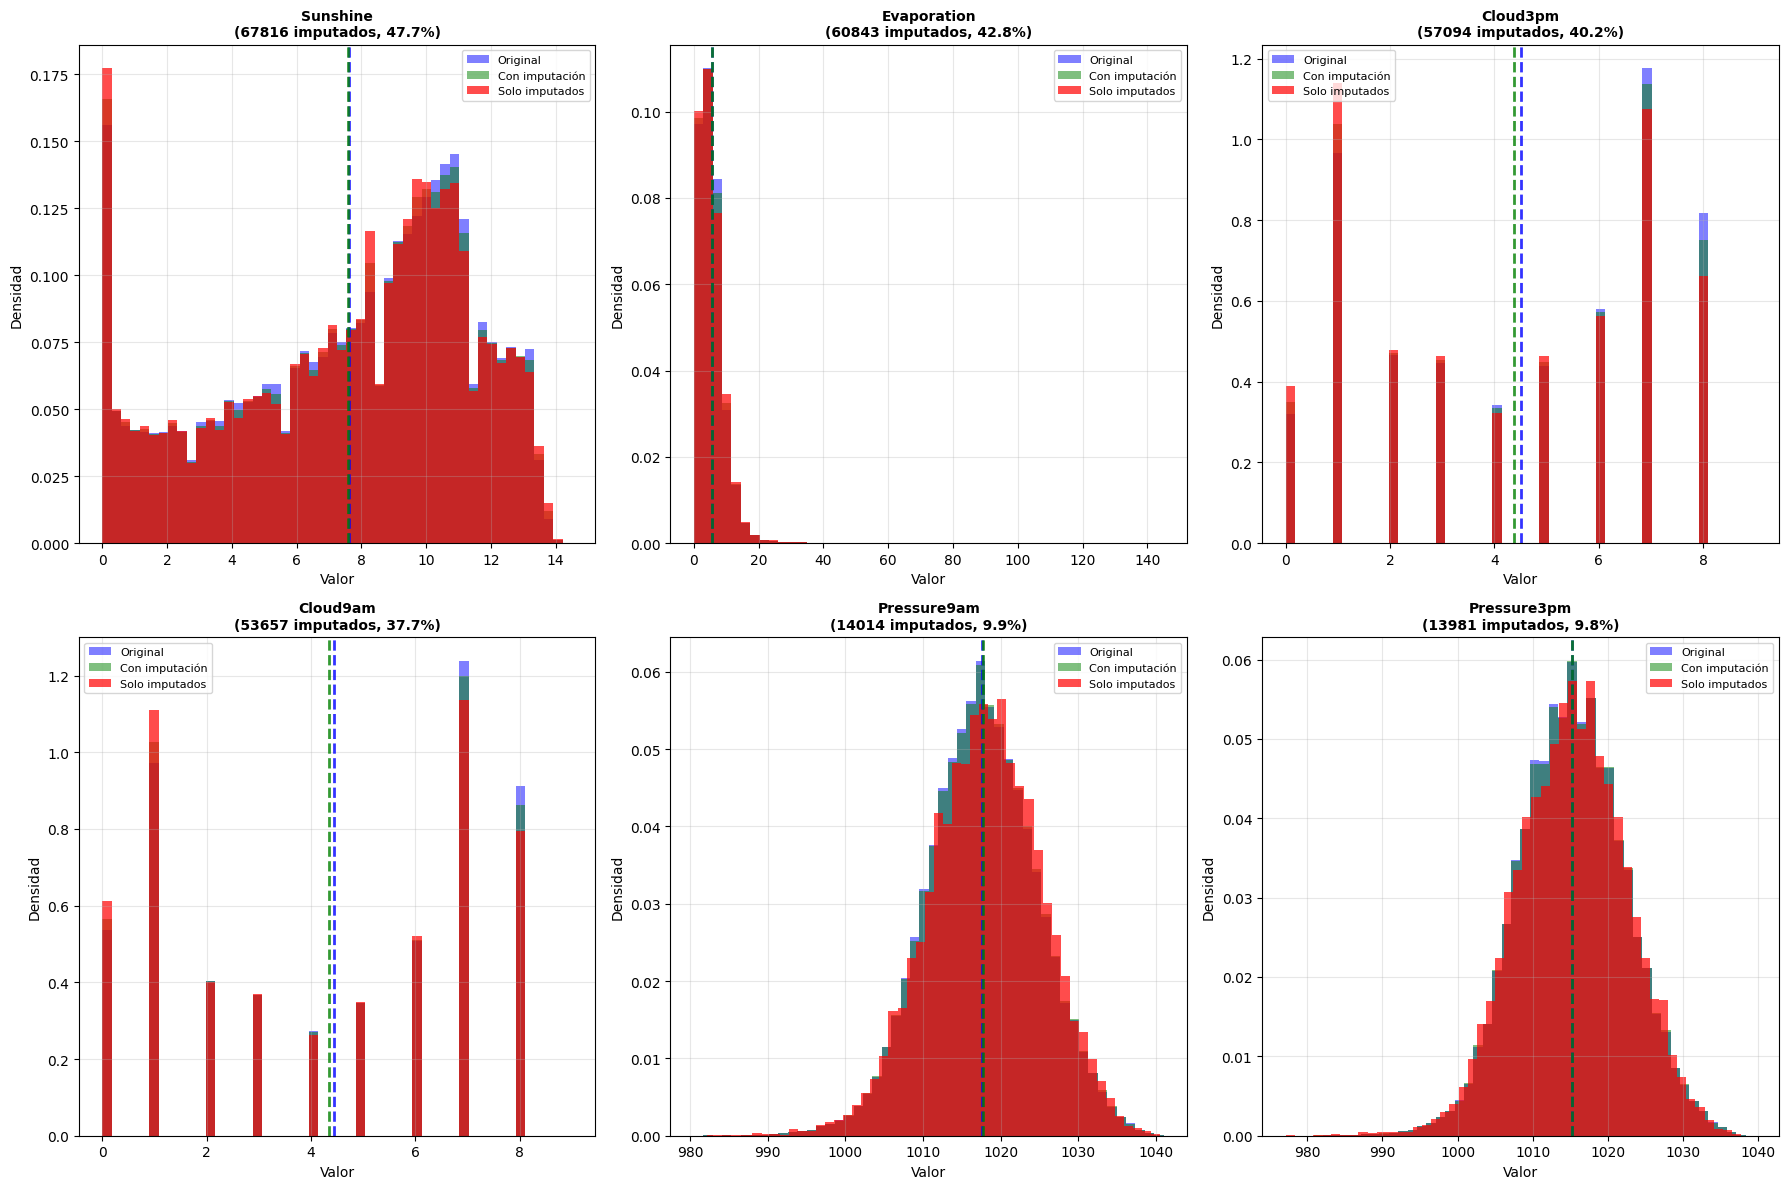


📊 Q-Q plots guardados como 'qq_plots_imputacion.png'


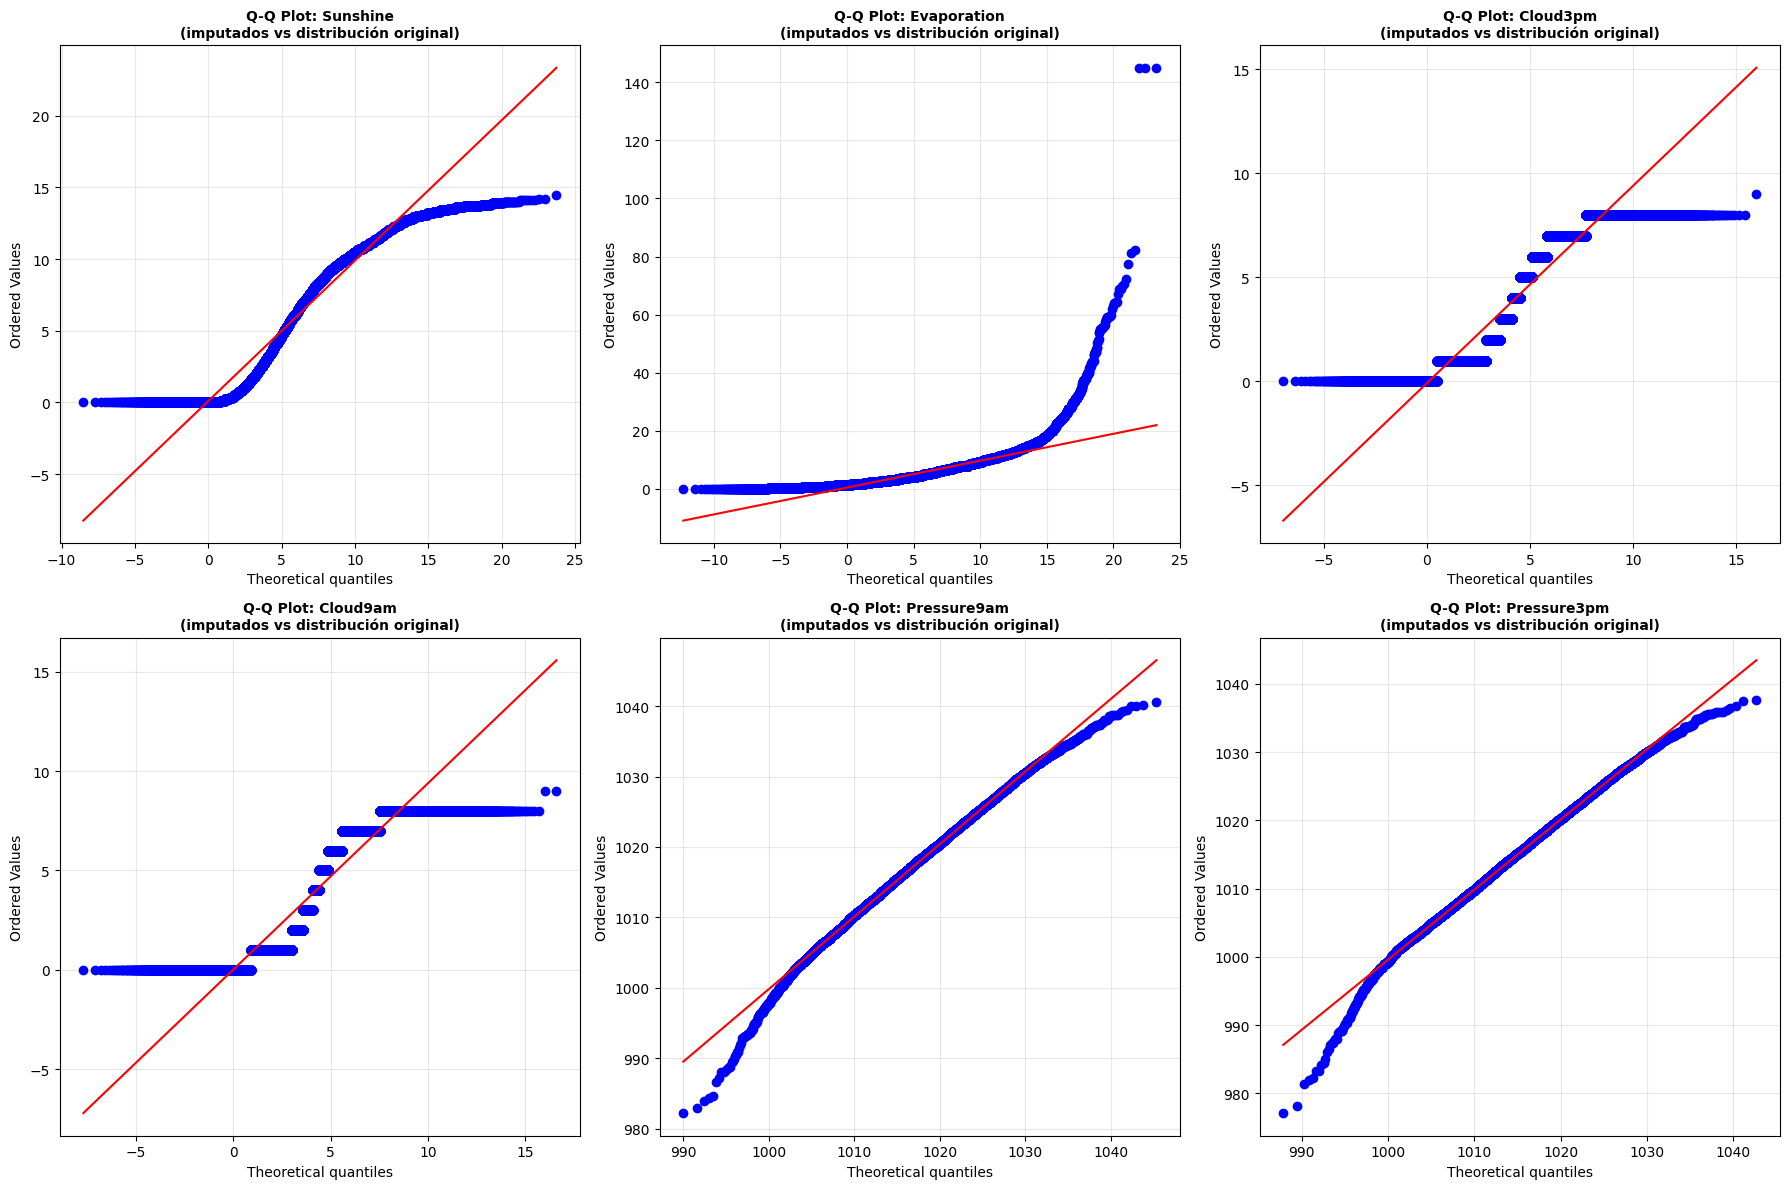

In [34]:

df_stats = analisis_completo_imputacion(df, df_imputado)


# df_stats = validar_imputacion(df, df_imputado)
# visualizar_comparacion_distribuciones(df, df_imputado, columnas=['MinTemp', 'MaxTemp', 'Rainfall'])
# visualizar_qq_plots(df, df_imputado)